In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]

import pandas as pd

%matplotlib inline



In [2]:
# Read datasets and set the index to be the date
df1 = pd.read_csv('../datasets/TX-Data/met_station/met_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met_station/met_2.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met_station/met_3.dat', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met_station/met_4.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met_station/met_5.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met_station/met_6.dat', sep=",", parse_dates=["Date"], index_col="Date")

# save dataframes into list
DF = [df1, df2, df3, df4, df5, df6]

In [3]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    
    
for df in DF:
    remove_spaces(df)


**Date:** Synchronized time stamps (CST)

**Tair:** air temperature (deg C)

**RH:** relative humidity (percentage): https://en.wikipedia.org/wiki/Humidity

**Wind speed:** meters/second

**Wind direction:** Degree

**Srad:** solar radiation (W/m^2) https://en.wikipedia.org/wiki/Solar_irradiance



These data are a little different from Houston data. But, soil moisture, precipitation, humidity, wind speed and direction and solar radiation are common parameters that we use. 


# Visualization of Annual MET Air Temperature

In [4]:
# Selects a feature from the MET data. Creates df with METs as a columns.
# Takes in list of MET dataframes and the selected feature as a string. 
def select_feature(DF, feature):
    df_feature = pd.concat(DF, axis=1)[feature]
    df_feature.columns = [str(f"MET{i}") for i in range(1, len(DF)+1)]
    return df_feature


# create df with only Air temp data of each MET
df_Tair = select_feature(DF, "Tair")
df_Tair

,MET1,MET2,MET3,MET4,MET5,MET6
Date,,,,,,
2014-10-01 00:00:00,22.13,NaN,NaN,NaN,NaN,NaN
2014-10-01 01:00:00,21.68,NaN,NaN,NaN,NaN,NaN
2014-10-01 02:00:00,22.21,NaN,NaN,NaN,NaN,NaN
2014-10-01 03:00:00,22.41,NaN,NaN,NaN,NaN,NaN
2014-10-01 04:00:00,22.30,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-08-31 20:00:00,29.10,NaN,28.24,29.94,29.81,31.41
2021-08-31 21:00:00,28.07,NaN,26.14,28.88,28.51,30.31
2021-08-31 22:00:00,27.73,NaN,24.94,28.19,27.77,29.99


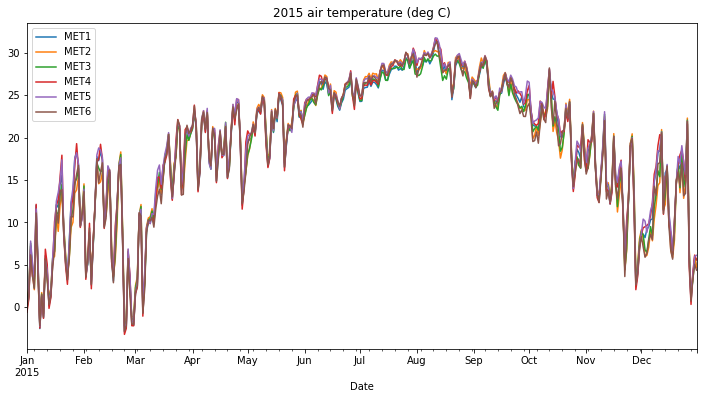

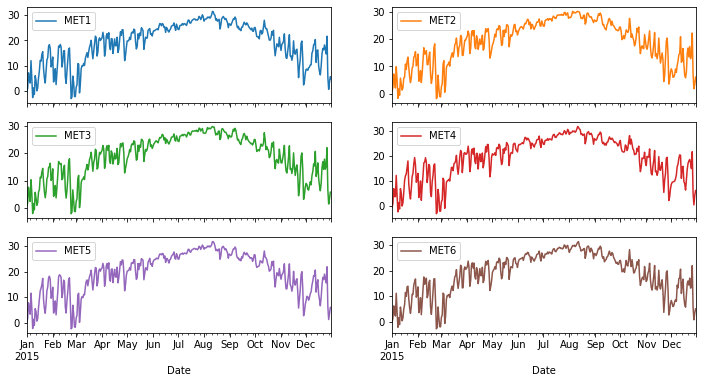

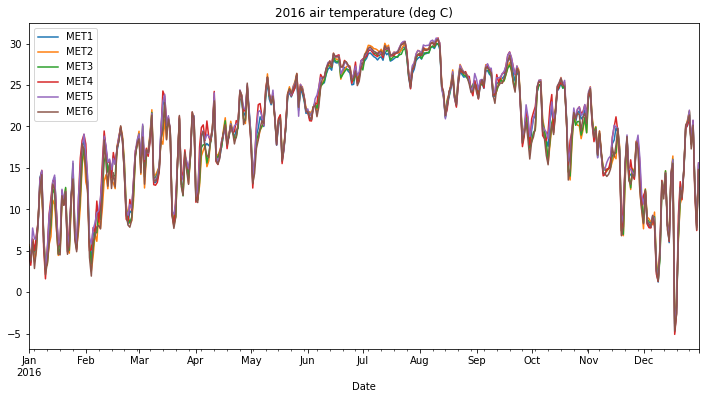

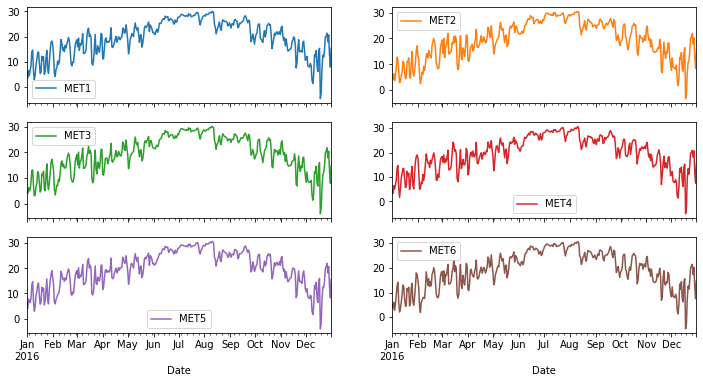

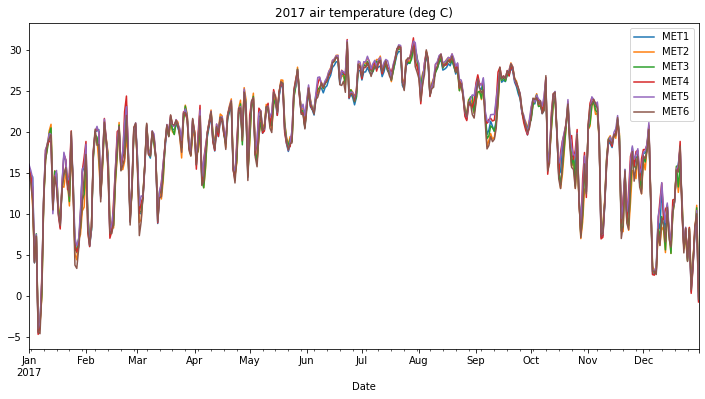

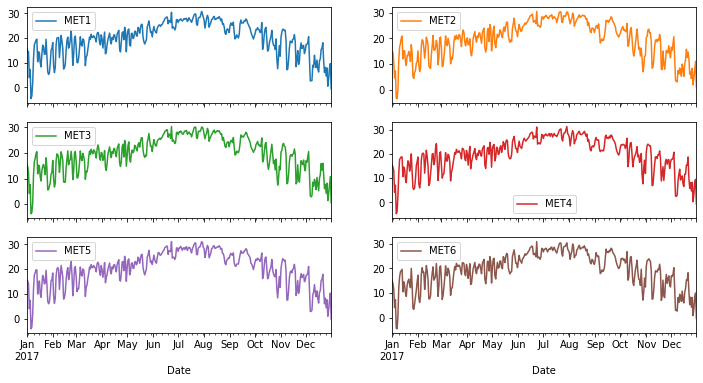

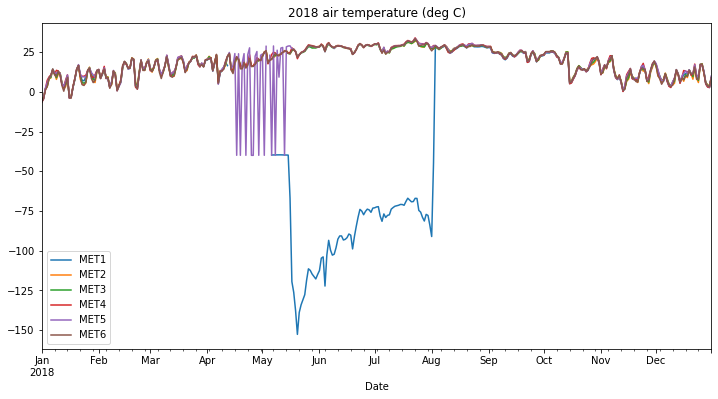

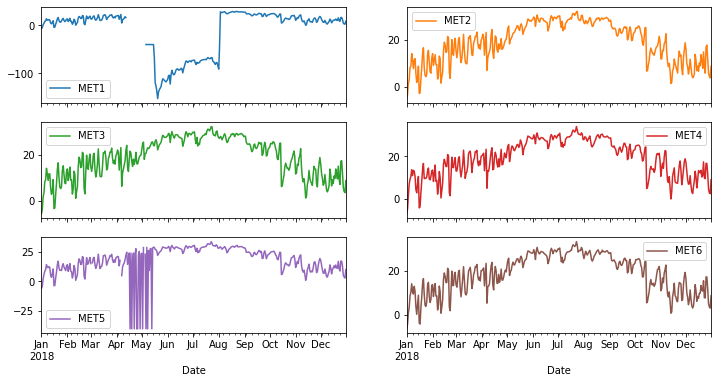

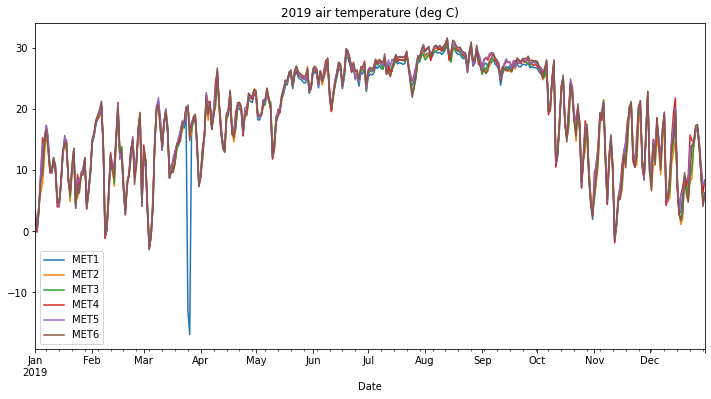

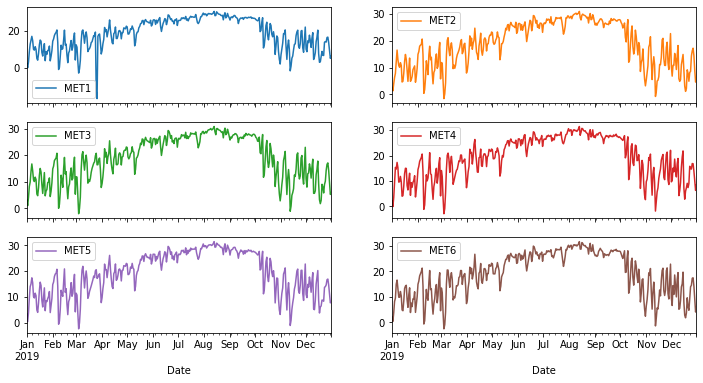

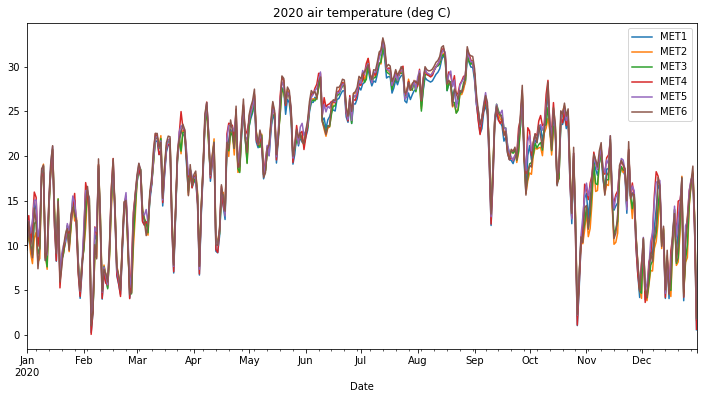

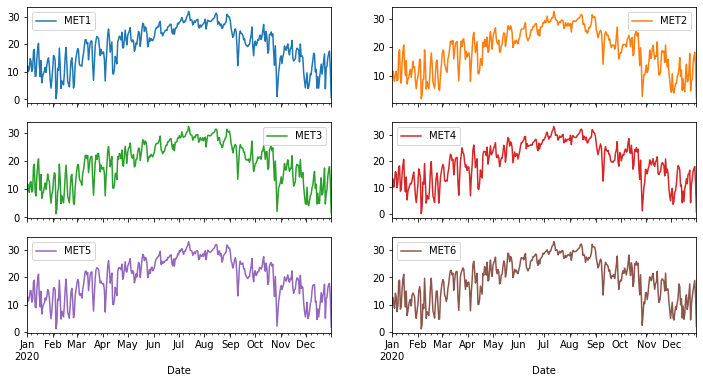

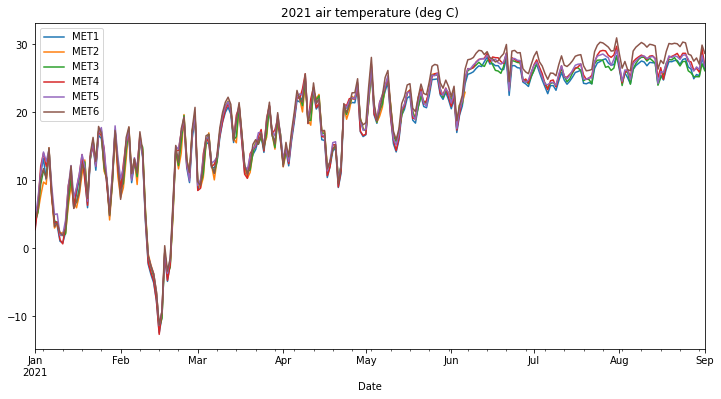

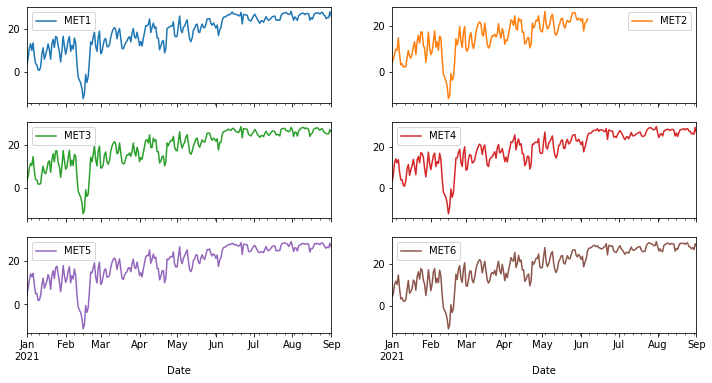

In [5]:
# Plots visual comparison of all METs annual Air Temp data. 
# Takes in df output of select_feature() and a string to be used as title
def plot_feature(df_feature, title):
    years = [str(yr) for yr in range(2015, 2022)]

    for yr in years:
        
        df_yr = df_Tair[yr].resample('D').mean()
        
        df_yr.plot(figsize=(12,6), title=f"{yr} {title}")
        df_yr.plot(figsize=(12,6), subplots=True, layout=(3,2))

        
plot_feature(df_Tair, "air temperature (deg C)")        
#plot_Tair(DF)

#### 2018: MET 1 and 5 have abnormally low values.  MET 1 and 5 April data missing.
#### 2019: MET 1 March data is inconsistent with other stations. 
#### 2021: MET 2 data missing from Jun to Sep.
Note:\
2021 data ends at September \
2021 February Winter Storm Uri hit Texas.

# Cleaning Air Temperature Data

Air temperature of each MET is very similar across the year. Annual means can be used to clean up data.

# 2018

In [6]:
# Exlude MET 1 and 5 Air Temp data from mean
df_2018_Tair_mean = df_Tair.drop(["MET1", "MET5"], axis=1).mean(axis=1)

### MET 5 cleaning

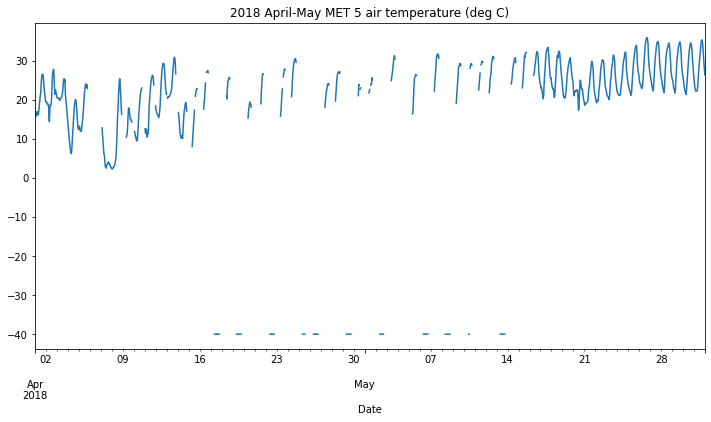

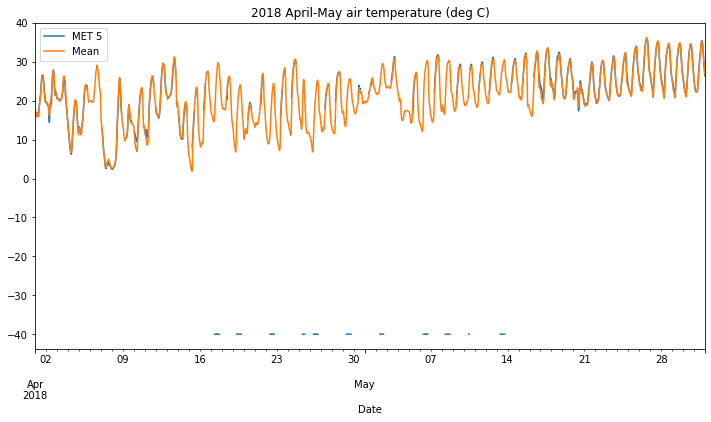

In [7]:
# Vizualize MET 5 Apr - May anomaly.
df_Tair["2018-4":"2018-5"].MET5.plot(figsize=(12,6), label=f"MET 5")
plt.title("2018 April-May MET 5 air temperature (deg C)")
plt.show()

# Compare MET 5 and mean
df_Tair["2018-4":"2018-5"].MET5.plot(figsize=(12,6), label=f"MET 5")
df_2018_Tair_mean["2018-4":"2018-5"].plot(figsize=(12,6), label=f"Mean")
plt.legend()
plt.title("2018 April-May air temperature (deg C)")
plt.show()


The data that is not missing is consistent with the mean - except for the abnormal lows near -40 C.\
Only use the mean on the missing and abnormally low data points. 

In [8]:
# cleaning functions

# imputes missing values with mean
def mean_imputation (df, df_mean):
    to_impute = df[df.isna() == True].index
    df[to_impute] = df_mean[to_impute]
    
    # document imputed indices
    return to_impute


# replaces values below given limit with mean
def mean_replace_low (df, df_mean, lim):
    to_replace = df[df < lim].index
    df[to_replace] = df_mean[to_replace]
    
    # document replaced indices
    return to_replace

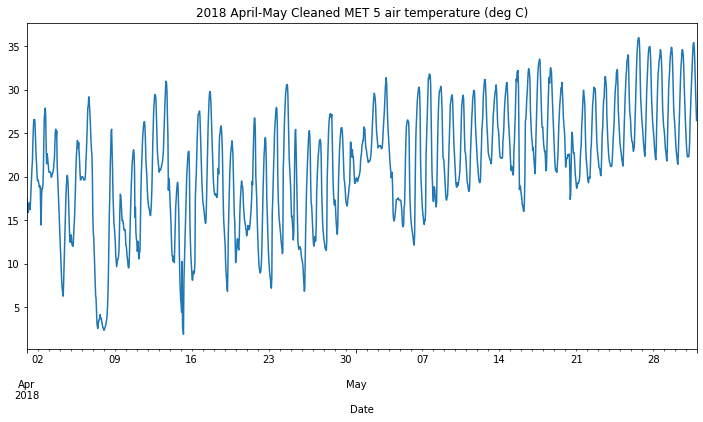

In [9]:
# Clean Data
# Record changed indices
MET5_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-5"].MET5, df_2018_Tair_mean)
MET5_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-5"].MET5, df_2018_Tair_mean, -20)

# Vizualize Cleaned MET 5 Apr - May.
df_Tair["2018-4":"2018-5"].MET5.plot(figsize=(12,6), label=f"MET 5")
plt.title("2018 April-May Cleaned MET 5 air temperature (deg C)")
plt.show()

### MET 1 cleaning

Repeat process with 2018 MET 1 data

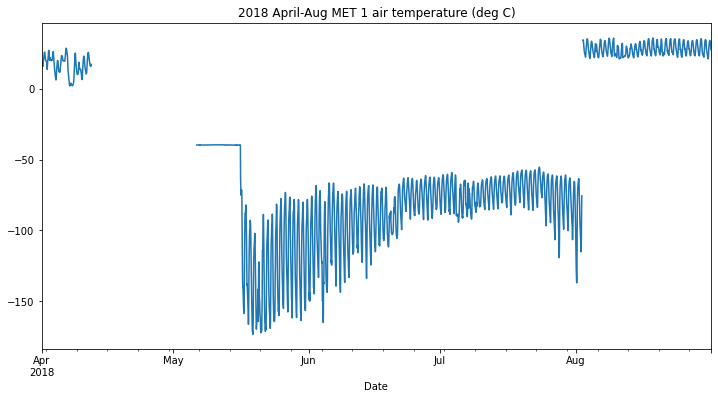

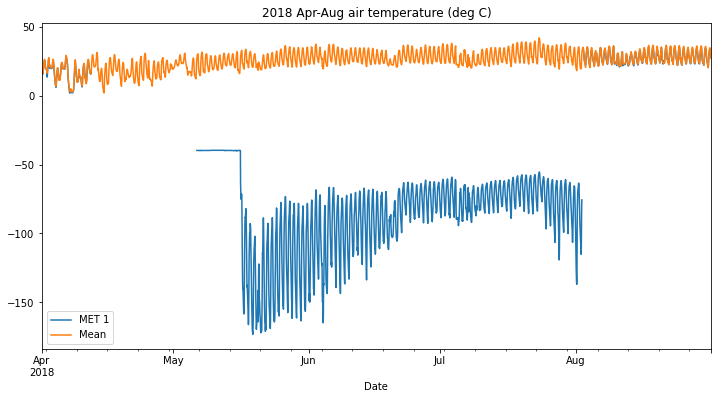

In [10]:
# Vizualize MET 1 Apr - Aug anomaly.
df_Tair["2018-4":"2018-8"].MET1.plot(figsize=(12,6), label=f"MET 1")
plt.title("2018 April-Aug MET 1 air temperature (deg C)")
plt.show()

# Compare MET 1 and mean
df_Tair["2018-4":"2018-8"].MET1.plot(figsize=(12,6), label=f"MET 1")
df_2018_Tair_mean["2018-4":"2018-8"].plot(figsize=(12,6), label=f"Mean")
plt.legend()
plt.title("2018 Apr-Aug air temperature (deg C)")
plt.show()



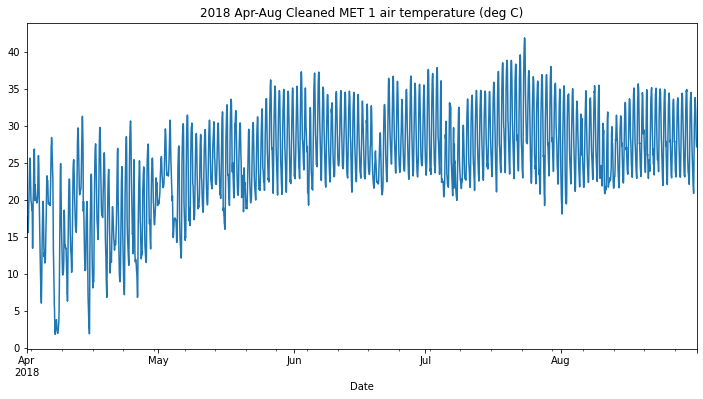

In [11]:
# Clean Data
# Record changed indices
MET1_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-8"].MET1, df_2018_Tair_mean)
MET1_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-8"].MET1, df_2018_Tair_mean, -10)

# Vizualize Cleaned MET 1 Apr - Aug.
df_Tair["2018-4":"2018-8"].MET1.plot(figsize=(12,6), label=f"MET 1")
plt.title("2018 Apr-Aug Cleaned MET 1 air temperature (deg C)")
plt.show()

# 2019

In [12]:
# Exlude MET 1 Air Temp data from mean
df_2019_Tair_mean = df_Tair.drop(["MET1"], axis=1).mean(axis=1)

### MET 1 cleaning

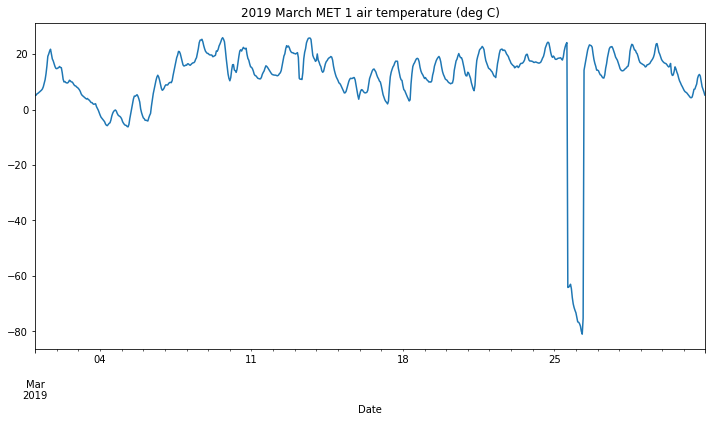

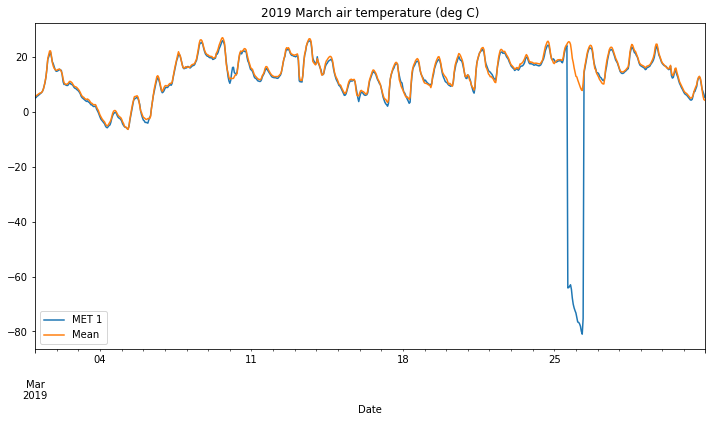

In [13]:
# Vizualize MET 1 March anomaly.
df_Tair["2019-3"].MET1.plot(figsize=(12,6), label=f"MET 1")
plt.title("2019 March MET 1 air temperature (deg C)")
plt.show()

# Compare MET 1 and mean
df_Tair["2019-3"].MET1.plot(figsize=(12,6), label=f"MET 1")
df_2019_Tair_mean["2019-3"].plot(figsize=(12,6), label=f"Mean")
plt.legend()
plt.title("2019 March air temperature (deg C)")
plt.show()

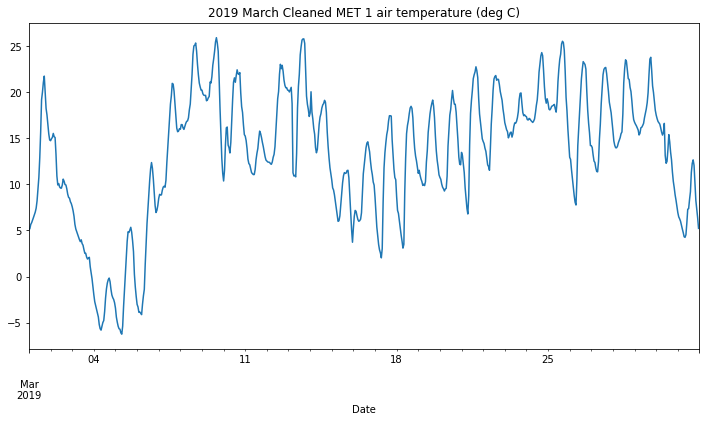

In [14]:
# Clean Data
# Record changed indices
MET1_2019_replaced = mean_replace_low (df_Tair["2019-3"].MET1, df_2019_Tair_mean, -20)

# Vizualize Cleaned MET 1 March.
df_Tair["2019-3"].MET1.plot(figsize=(12,6), label=f"MET 1")
plt.title("2019 March Cleaned MET 1 air temperature (deg C)")
plt.show()

# 2021

In [15]:
# Exlude MET 2 Air Temp data from mean
df_2021_Tair_mean = df_Tair.drop(["MET2"], axis=1).mean(axis=1)

### MET 2 cleaning

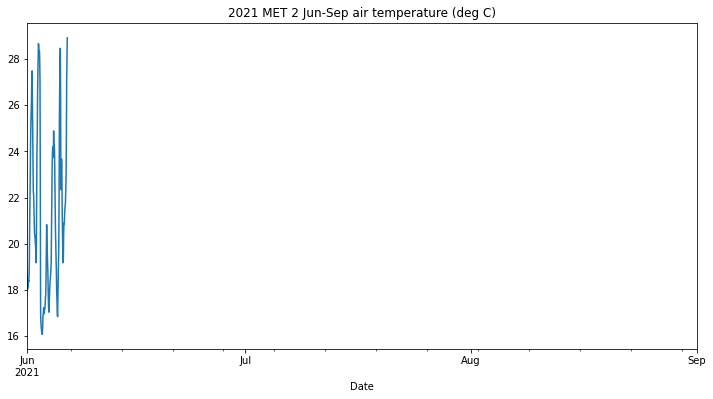

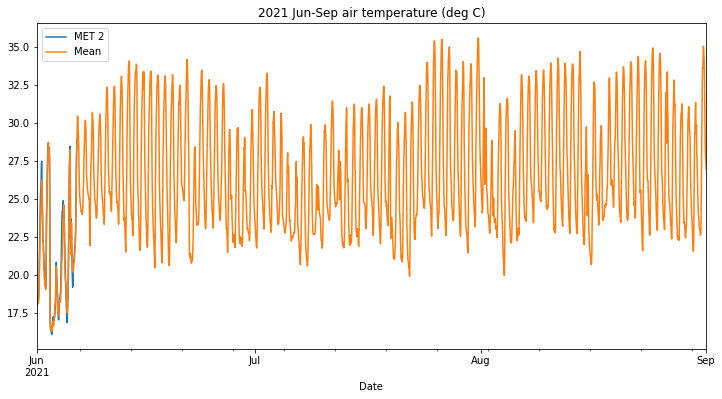

In [16]:
# Vizualize MET 2.
df_Tair["2021-6":"2021-9"].MET2.plot(figsize=(12,6), label=f"MET 2")
plt.title("2021 MET 2 Jun-Sep air temperature (deg C)")
plt.show()

# Compare MET 2 and mean
df_Tair["2021-6":"2021-9"].MET2.plot(figsize=(12,6), label=f"MET 2")
df_2021_Tair_mean["2021-6":"2021-9"].plot(figsize=(12,6), label=f"Mean")
plt.legend()
plt.title("2021 Jun-Sep air temperature (deg C)")
plt.show()

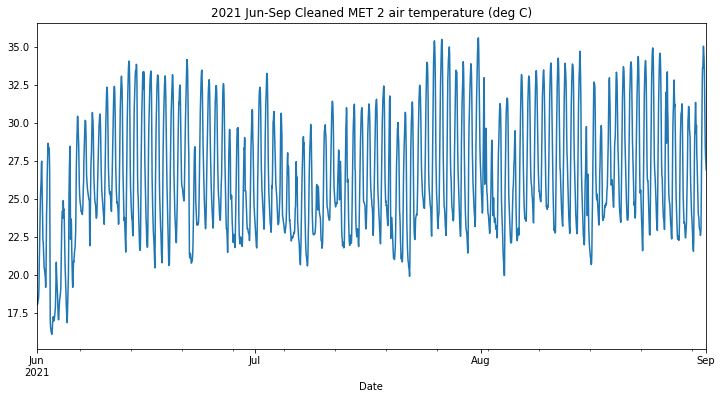

In [17]:
# Clean Data
# Record changed indices
MET2_2021_imputed = mean_imputation (df_Tair["2021-6":"2021-9"].MET2, df_2021_Tair_mean)

# Vizualize Cleaned MET 2.
df_Tair["2021-6":"2021-9"].MET2.plot(figsize=(12,6), label=f"MET 2")
plt.title("2021 Jun-Sep Cleaned MET 2 air temperature (deg C)")
plt.show()

Data Cleaning is done. For documentation, show indices that were changed.

In [18]:
# Concatenate and sort changed indices for each MET
MET1_changed_idx = pd.to_datetime(np.sort(np.append(MET1_2018_replaced, pd.to_datetime(MET1_2018_imputed, MET1_2019_replaced))))
MET2_changed_idx = MET2_2021_imputed
MET5_changed_idx = pd.to_datetime(np.sort(np.append(MET5_2018_imputed, MET5_2018_replaced)))

# print results
print("Indices Changed during Cleaning:\n")
print("MET 1")
print(MET1_changed_idx, "\n")
print("MET 2")
print(MET2_changed_idx, "\n")
print("MET 5")
print(MET5_changed_idx, "\n")
print("No Change to MET 3, MET 4, and MET 6")

Indices Changed during Cleaning:

MET 1
DatetimeIndex(['2018-04-12 09:00:00', '2018-04-12 10:00:00',
               '2018-04-12 11:00:00', '2018-04-12 12:00:00',
               '2018-04-12 13:00:00', '2018-04-12 14:00:00',
               '2018-04-12 15:00:00', '2018-04-12 16:00:00',
               '2018-04-12 17:00:00', '2018-04-12 18:00:00',
               ...
               '2018-08-02 06:00:00', '2018-08-02 07:00:00',
               '2018-08-02 08:00:00', '2018-08-02 09:00:00',
               '2018-08-02 10:00:00', '2018-08-02 11:00:00',
               '2018-08-02 12:00:00', '2018-08-02 13:00:00',
               '2018-08-02 14:00:00', '2018-08-02 15:00:00'],
              dtype='datetime64[ns]', length=2695, freq=None) 

MET 2
DatetimeIndex(['2021-06-06 14:00:00', '2021-06-06 15:00:00',
               '2021-06-06 16:00:00', '2021-06-06 17:00:00',
               '2021-06-06 18:00:00', '2021-06-06 19:00:00',
               '2021-06-06 20:00:00', '2021-06-06 21:00:00',
               '

# Visualization of Results

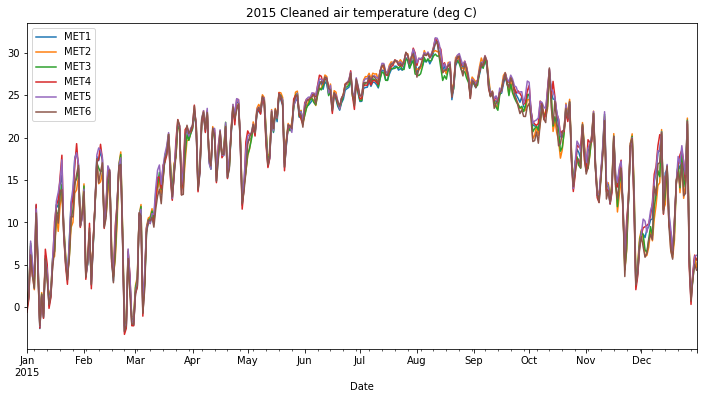

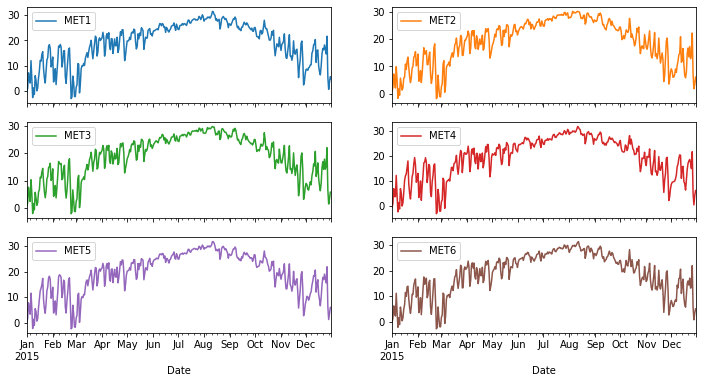

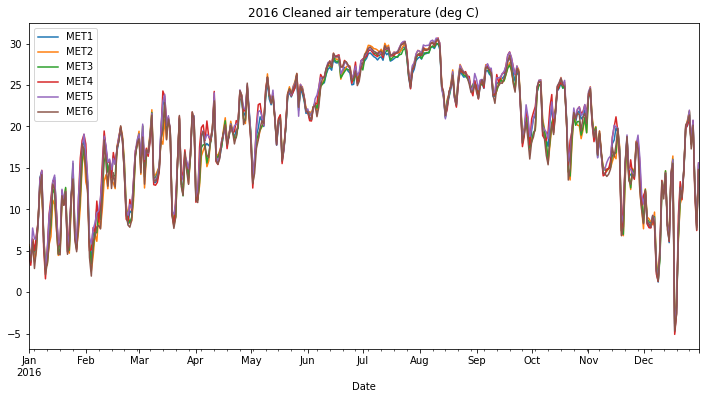

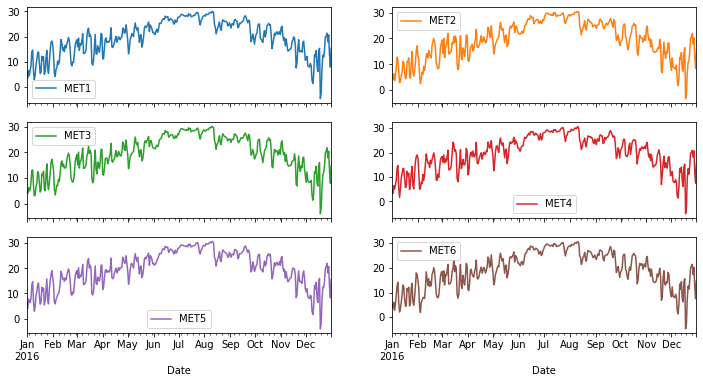

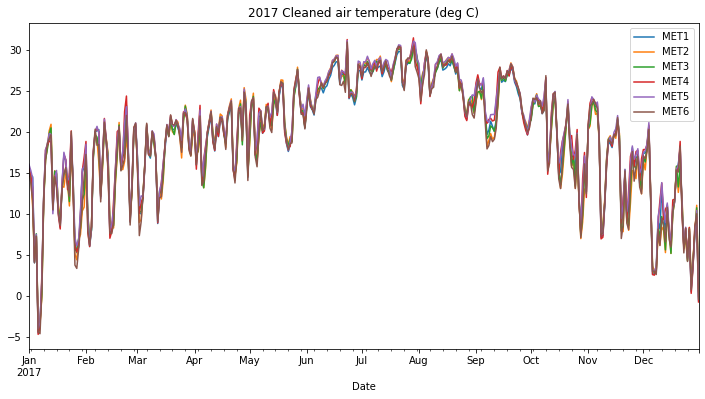

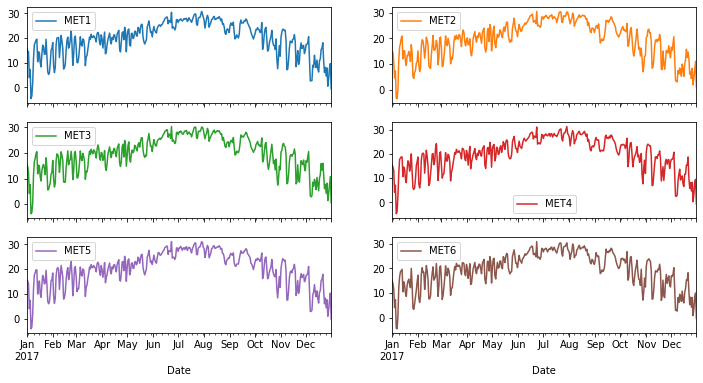

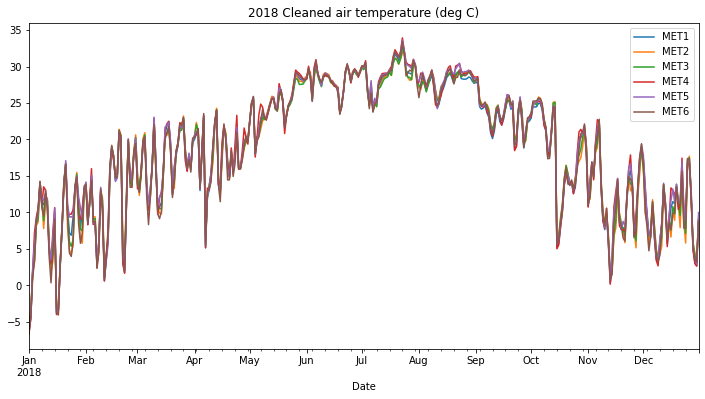

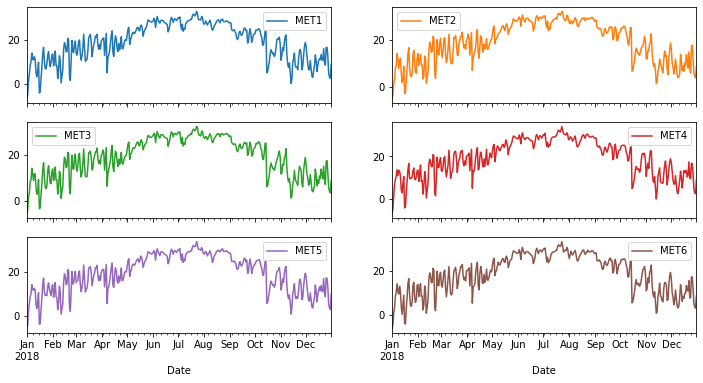

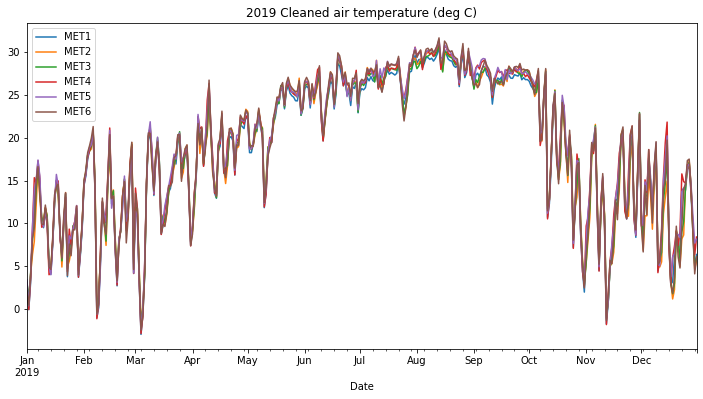

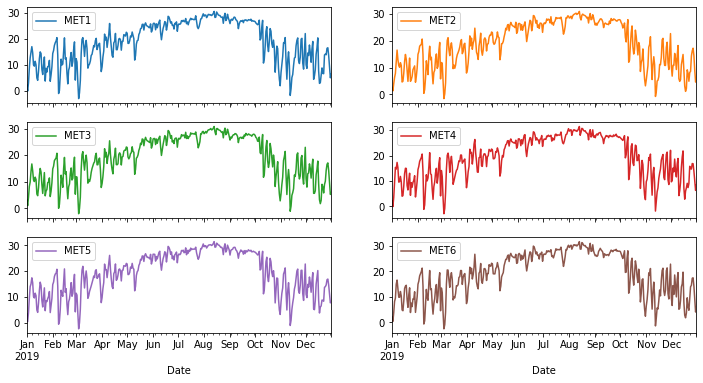

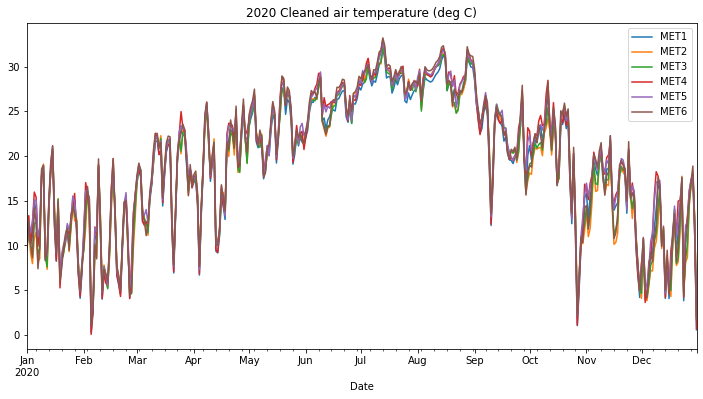

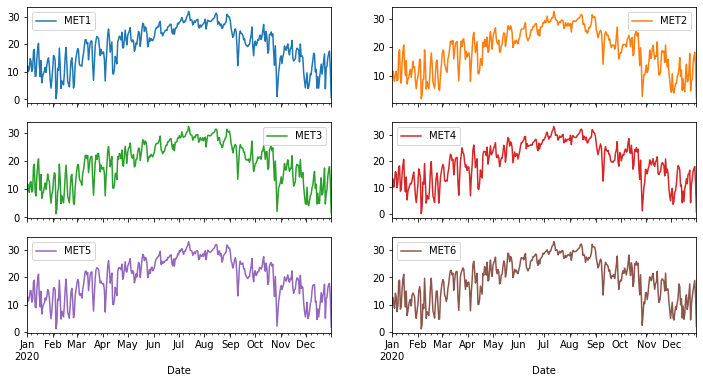

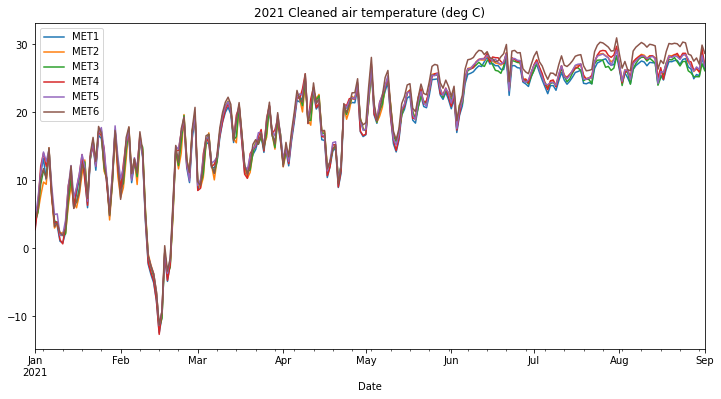

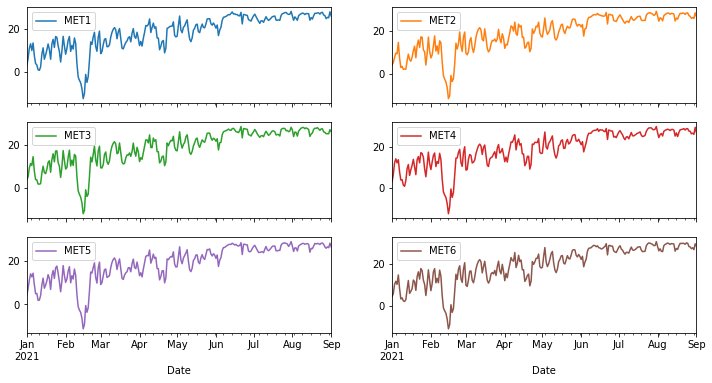

In [19]:
# Plot cleaned data
plot_feature(df_Tair, "Cleaned air temperature (deg C)")